# 05 — Bayesian Decision Rule (Classical Pipeline)

## Theory

Bayes' theorem gives the posterior for a general prior P(ω_i):

$$P(\omega_i \mid x) = \frac{p(x\mid\omega_i)\,P(\omega_i)}{\sum_j p(x\mid\omega_j)\,P(\omega_j)}$$

The priors P(ω_M) and P(ω_B) are computed **explicitly** from the training labels (not assumed equal).

**MAP rule** — minimises 0-1 loss:  
predict melanoma if P(ω_M | x) > P(ω_B | x)   ⟺   posterior > 0.5 when priors are equal

**Cost-sensitive rule** — minimises expected conditional risk R(α_i | x) = Σ_j λ(α_i | ω_j) P(ω_j | x):  
predict melanoma when R(α_melanoma | x) < R(α_benign | x)  
⟹ predict melanoma if P(ω_M | x) > λ(FP) / (λ(FP) + λ(FN)) = 1 / (1 + 5) = **1/6**

## Numerical stability

`score_samples` returns log p(x|ω_i).  Adding log P(ω_i) gives log[p(x|ω_i)·P(ω_i)].  
The normaliser is computed with `np.logaddexp` to avoid any exp of large negatives:

$$\log Z = \log\!\bigl[p(x|\omega_M)P(\omega_M) + p(x|\omega_B)P(\omega_B)\bigr]
         = \mathrm{logaddexp}\!\bigl(\ell_M + \log P(\omega_M),\; \ell_B + \log P(\omega_B)\bigr)$$

$$P(\omega_M \mid x) = \exp\!\bigl(\ell_M + \log P(\omega_M) - \log Z\bigr)$$

In [1]:
import os
import sys
from pathlib import Path

_cwd = Path(os.getcwd())
for _root in [_cwd, *_cwd.parents]:
    if (_root / "skin_lesion" / "src" / "config.py").exists():
        sys.path.insert(0, str(_root / "skin_lesion" / "src"))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay)

from config import SEED, PROCESSED_DIR, FIGURES_DIR, TABLES_DIR, COST_FN, COST_FP, COST_MATRIX, HSV_BINS

## 1 — Load splits and GMMs

In [2]:
data = np.load(PROCESSED_DIR / "splits.npz")
X_train, y_train = data["X_train"], data["y_train"]
X_val,   y_val   = data["X_val"],   data["y_val"]
X_test,  y_test  = data["X_test"],  data["y_test"]

gmm_benign   = joblib.load(PROCESSED_DIR / "gmm_benign.pkl")
gmm_melanoma = joblib.load(PROCESSED_DIR / "gmm_melanoma.pkl")

print(f"Train: {len(y_train)} samples")
print(f"Val  : {len(y_val)}  samples")
print(f"Test : {len(y_test)} samples")
print(f"GMM benign   — K={gmm_benign.n_components},   cov='{gmm_benign.covariance_type}'")
print(f"GMM melanoma — K={gmm_melanoma.n_components}, cov='{gmm_melanoma.covariance_type}'")

Train: 1335 samples
Val  : 445  samples
Test : 446 samples
GMM benign   — K=2,   cov='full'
GMM melanoma — K=1, cov='full'


## 1b — Explicit class priors

Priors are estimated from the **training** labels — never from val or test.

In [3]:
# ── Explicit class priors (estimated from training labels) ─────────────────
prior_mel = float(y_train.mean())       # P(ω_M)
prior_ben = 1.0 - prior_mel             # P(ω_B)

print(f"Prior P(melanoma) = {prior_mel:.6f}")
print(f"Prior P(benign)   = {prior_ben:.6f}")
print(f"(sum = {prior_mel + prior_ben:.6f})")

Prior P(melanoma) = 0.500375
Prior P(benign)   = 0.499625
(sum = 1.000000)


## 2 — Posterior computation (general Bayes rule, numerically stable)

`GaussianMixture.score_samples(X)` returns log p(x|ω).  
Adding log P(ω_i) gives the log-numerator; `np.logaddexp` computes the log-normaliser without ever exponentiating large negatives:

$$P(\omega_M \mid x) = \exp\!\bigl(\log p(x|\omega_M) + \log P(\omega_M) - \mathrm{logaddexp}(\cdots)\bigr)$$

In [4]:
def compute_posterior(X, gmm_mel, gmm_ben, prior_mel=0.5, prior_ben=0.5):
    """
    P(ω_M | x) for each row in X via the general Bayes rule.

    Uses log-space arithmetic (np.logaddexp for the normaliser) so it is
    numerically safe even for very large or very small log-likelihoods.

    Parameters
    ----------
    X         : (N, D) feature matrix
    gmm_mel   : fitted GaussianMixture for the melanoma class
    gmm_ben   : fitted GaussianMixture for the benign class
    prior_mel : P(ω_M) — scalar prior for melanoma
    prior_ben : P(ω_B) — scalar prior for benign  (must sum to 1 with prior_mel)

    Returns
    -------
    (N,) array of P(ω_M | x) values in [0, 1]
    """
    log_p_mel = gmm_mel.score_samples(X)          # log p(x | ω_M)
    log_p_ben = gmm_ben.score_samples(X)           # log p(x | ω_B)

    log_num = log_p_mel + np.log(prior_mel)        # log[ p(x|ω_M) · P(ω_M) ]
    log_den = log_p_ben + np.log(prior_ben)        # log[ p(x|ω_B) · P(ω_B) ]
    log_evidence = np.logaddexp(log_num, log_den)  # log normaliser (numerically stable)

    return np.exp(np.clip(log_num - log_evidence, -500, 0))


post_val  = compute_posterior(X_val,  gmm_melanoma, gmm_benign, prior_mel, prior_ben)
post_test = compute_posterior(X_test, gmm_melanoma, gmm_benign, prior_mel, prior_ben)

print(f"Posterior P(mel|x) — val  : mean={post_val.mean():.4f}, "
      f"min={post_val.min():.4f}, max={post_val.max():.4f}")
print(f"Posterior P(mel|x) — test : mean={post_test.mean():.4f}, "
      f"min={post_test.min():.4f}, max={post_test.max():.4f}")

Posterior P(mel|x) — val  : mean=0.5350, min=0.0000, max=1.0000
Posterior P(mel|x) — test : mean=0.5412, min=0.0000, max=1.0000


## 3 — Conditional risk and decision rules

The **conditional risk** of action α_i given observation x is:

$$R(\alpha_i \mid x) = \sum_j \lambda(\alpha_i \mid \omega_j)\, P(\omega_j \mid x)$$

The **minimum-risk** (Bayes-optimal) decision is the action with the lowest conditional risk.  
With the 2×2 cost matrix from `config.py` this reduces to two specific thresholds:

| Rule | Threshold | Derivation |
|------|-----------|-----------|
| MAP (0-1 loss) | θ = 0.5 | λ symmetric ⟹ argmin R = argmax P(ω\|x) |
| Cost-sensitive | θ = λ(FP)/(λ(FP)+λ(FN)) = 1/6 | R(α_mel\|x) < R(α_ben\|x) ⟺ P(ω_M\|x) > 1/6 |

`min_risk_decision` implements the **general** form (matrix multiplication) and is verified to match the analytic thresholds.

In [5]:
def conditional_risk(posteriors_2d, cost_matrix):
    """
    R(α_i | x) = Σ_j λ(α_i | ω_j) · P(ω_j | x)  for every sample and action.

    Parameters
    ----------
    posteriors_2d : (N, C) array  — P(ω_j | x); rows sum to 1
    cost_matrix   : (A, C) array  — λ[i, j] = cost of action i when true class is j

    Returns
    -------
    risks : (N, A) array — conditional risk for each sample × action
    """
    return posteriors_2d @ cost_matrix.T     # (N, C) × (C, A) → (N, A)


def min_risk_decision(posteriors_2d, cost_matrix):
    """Return the minimum-risk action index (0=benign, 1=melanoma) for each sample."""
    return np.argmin(conditional_risk(posteriors_2d, cost_matrix), axis=1)


# ── Build (N, 2) posterior matrices: col-0 = P(benign|x), col-1 = P(mel|x) ──
post_2d_val  = np.column_stack([1 - post_val,  post_val])
post_2d_test = np.column_stack([1 - post_test, post_test])

# ── Verify: min-risk decisions must match the analytic cost-sensitive threshold ─
THRESH_COST = COST_FP / (COST_FP + COST_FN)   # 1/6 ≈ 0.1667

y_risk_test = min_risk_decision(post_2d_test, COST_MATRIX)
y_thr_test  = (post_test >= THRESH_COST).astype(int)

assert np.array_equal(y_risk_test, y_thr_test), \
    "min_risk_decision and cost-sensitive threshold diverged — check cost matrix!"
print("Verification passed: min_risk_decision == cost-sensitive threshold for all test samples.")
print(f"Cost-sensitive threshold : {THRESH_COST:.6f}  "
      f"(= COST_FP / (COST_FP + COST_FN) = {COST_FP} / {COST_FP + COST_FN})")


Verification passed: min_risk_decision == cost-sensitive threshold for all test samples.
Cost-sensitive threshold : 0.166667  (= COST_FP / (COST_FP + COST_FN) = 1.0 / 6.0)


In [6]:
THRESH_MAP = 0.5

print(f"MAP threshold            : {THRESH_MAP}")
print(f"Cost-sensitive threshold : {THRESH_COST:.6f}  (= {int(COST_FP)}/{int(COST_FP+COST_FN)})\n")


def evaluate(y_true, posterior, threshold, rule_name, split_name):
    y_pred = (posterior >= threshold).astype(int)
    cm     = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc  = accuracy_score(y_true, y_pred)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # recall for melanoma (TPR)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0   # recall for benign  (TNR)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0   # precision for melanoma
    f1   = (2 * prec * sens / (prec + sens)) if (prec + sens) > 0 else 0.0
    cost = COST_FN * fn + COST_FP * fp
    print(f"[{split_name} | {rule_name}]")
    print(f"  Accuracy={acc:.4f}  Sensitivity={sens:.4f}  Specificity={spec:.4f}")
    print(f"  Precision={prec:.4f}  F1={f1:.4f}")
    print(f"  FN={fn}  FP={fp}  Total cost={cost:.0f}\n")
    return dict(rule=rule_name, split=split_name, threshold=round(threshold, 6),
                accuracy=round(acc, 4), sensitivity=round(sens, 4),
                specificity=round(spec, 4), precision=round(prec, 4),
                f1=round(f1, 4), FN=int(fn), FP=int(fp),
                total_cost=int(cost), cm=cm)


records = []
for split_name, y_true, post in [("val",  y_val,  post_val),
                                  ("test", y_test, post_test)]:
    records.append(evaluate(y_true, post, THRESH_MAP,  "MAP",            split_name))
    records.append(evaluate(y_true, post, THRESH_COST, "cost-sensitive", split_name))


MAP threshold            : 0.5
Cost-sensitive threshold : 0.166667  (= 1/6)

[val | MAP]
  Accuracy=0.7910  Sensitivity=0.8288  Specificity=0.7534
  Precision=0.7699  F1=0.7983
  FN=38  FP=55  Total cost=245

[val | cost-sensitive]
  Accuracy=0.7798  Sensitivity=0.8288  Specificity=0.7309
  Precision=0.7541  F1=0.7897
  FN=38  FP=60  Total cost=250

[test | MAP]
  Accuracy=0.7937  Sensitivity=0.8386  Specificity=0.7489
  Precision=0.7695  F1=0.8026
  FN=36  FP=56  Total cost=236

[test | cost-sensitive]
  Accuracy=0.7915  Sensitivity=0.8430  Specificity=0.7399
  Precision=0.7642  F1=0.8017
  FN=35  FP=58  Total cost=233



In [8]:
def threshold_shift_analysis(y_true, posterior, low, high, split_name):
    mask = (posterior >= low) & (posterior < high)
    n = mask.sum()
    n_mel = ((y_true == 1) & mask).sum()
    n_nev = ((y_true == 0) & mask).sum()

    print(f"{split_name}: samples flipped from MAP benign to cost-sensitive melanoma")
    print(f"  total flipped: {n}")
    print(f"  true melanoma among flipped: {n_mel}")
    print(f"  true nevus among flipped: {n_nev}")

threshold_shift_analysis(y_val, post_val, THRESH_COST, THRESH_MAP, "val")
threshold_shift_analysis(y_test, post_test, THRESH_COST, THRESH_MAP, "test")

val: samples flipped from MAP benign to cost-sensitive melanoma
  total flipped: 5
  true melanoma among flipped: 0
  true nevus among flipped: 5
test: samples flipped from MAP benign to cost-sensitive melanoma
  total flipped: 3
  true melanoma among flipped: 1
  true nevus among flipped: 2


## 4 — Confusion matrices on the test set

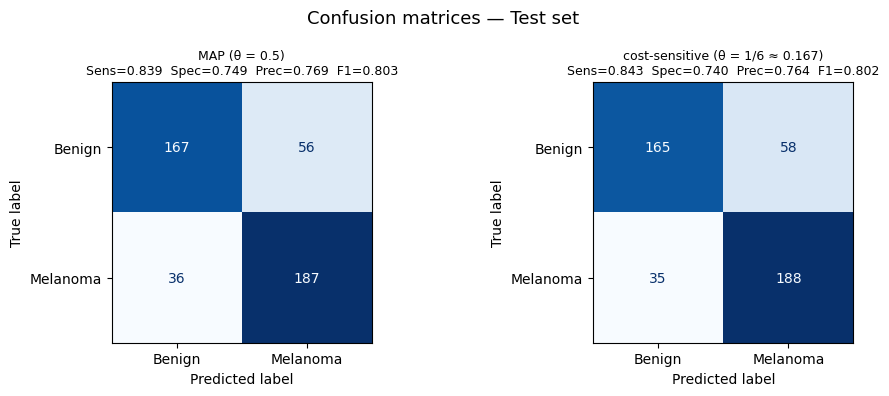

Figure saved to: C:\Users\tella\Projects\skin_lesion_triage\skin_lesion\results\figures\confusion_matrices.png


In [9]:
test_records = {r["rule"]: r for r in records if r["split"] == "test"}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Confusion matrices — Test set", fontsize=13)

for ax, (rule, res) in zip(axes, test_records.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=res["cm"],
        display_labels=["Benign", "Melanoma"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    thresh_label = "0.5" if rule == "MAP" else "1/6 ≈ 0.167"
    ax.set_title(f"{rule} (θ = {thresh_label})\n"
                 f"Sens={res['sensitivity']:.3f}  Spec={res['specificity']:.3f}  "
                 f"Prec={res['precision']:.3f}  F1={res['f1']:.3f}",
                 fontsize=9)

plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURES_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved to: {FIGURES_DIR / 'confusion_matrices.png'}")


## 5 — Summary table

In [10]:
summary_cols = ["rule", "threshold", "accuracy", "sensitivity",
                "specificity", "precision", "f1", "FN", "FP", "total_cost"]
test_df = pd.DataFrame(
    [{k: r[k] for k in summary_cols} for r in records if r["split"] == "test"]
)
print(test_df.to_string(index=False))

TABLES_DIR.mkdir(parents=True, exist_ok=True)
test_df.to_csv(TABLES_DIR / "decision_comparison.csv", index=False)
print(f"\nSaved to: {TABLES_DIR / 'decision_comparison.csv'}")


          rule  threshold  accuracy  sensitivity  specificity  precision     f1  FN  FP  total_cost
           MAP   0.500000    0.7937       0.8386       0.7489     0.7695 0.8026  36  56         236
cost-sensitive   0.166667    0.7915       0.8430       0.7399     0.7642 0.8017  35  58         233

Saved to: C:\Users\tella\Projects\skin_lesion_triage\skin_lesion\results\tables\decision_comparison.csv


## 7 — Unified run configuration log

All parameters that define this experimental run are written to a single `run_config.json`  
so that any result can be exactly reproduced from a single artefact (slide 20 requirement).

Fields logged: seed, split ratios, feature type, HSV bins, priors,  
GMM components (K) and covariance type per class, full cost matrix, both decision thresholds.

In [11]:
import json

run_config = {
    "seed":         int(SEED),
    "split": {
        "train_frac": 0.60,
        "val_frac":   0.20,
        "test_frac":  0.20,
        "stratified": True,
        "n_train":    int(len(y_train)),
        "n_val":      int(len(y_val)),
        "n_test":     int(len(y_test)),
    },
    "feature": {
        "type":     "HSV histogram",
        "hsv_bins": list(HSV_BINS),
        "dim":      int(sum(HSV_BINS)),
    },
    "priors": {
        "melanoma": round(prior_mel, 6),
        "benign":   round(prior_ben, 6),
    },
    "gmm": {
        "melanoma": {
            "K":           int(gmm_melanoma.n_components),
            "cov_type":    gmm_melanoma.covariance_type,
            "converged":   bool(gmm_melanoma.converged_),
            "n_iter":      int(gmm_melanoma.n_iter_),
        },
        "benign": {
            "K":           int(gmm_benign.n_components),
            "cov_type":    gmm_benign.covariance_type,
            "converged":   bool(gmm_benign.converged_),
            "n_iter":      int(gmm_benign.n_iter_),
        },
    },
    "cost_matrix": {
        "lambda_FN":   COST_FN,
        "lambda_FP":   COST_FP,
        "matrix_rows_actions_cols_classes": COST_MATRIX.tolist(),
        "action_labels": ["predict_benign", "predict_melanoma"],
        "class_labels":  ["benign", "melanoma"],
    },
    "thresholds": {
        "MAP":            THRESH_MAP,
        "cost_sensitive": round(THRESH_COST, 8),
    },
}

TABLES_DIR.mkdir(parents=True, exist_ok=True)
config_path = TABLES_DIR / "run_config.json"
with open(config_path, "w") as f:
    json.dump(run_config, f, indent=2)

print(f"Run config saved to: {config_path}")
print(json.dumps(run_config, indent=2))

Run config saved to: C:\Users\tella\Projects\skin_lesion_triage\skin_lesion\results\tables\run_config.json
{
  "seed": 42,
  "split": {
    "train_frac": 0.6,
    "val_frac": 0.2,
    "test_frac": 0.2,
    "stratified": true,
    "n_train": 1335,
    "n_val": 445,
    "n_test": 446
  },
  "feature": {
    "type": "HSV histogram",
    "hsv_bins": [
      32,
      32,
      32
    ],
    "dim": 96
  },
  "priors": {
    "melanoma": 0.500375,
    "benign": 0.499625
  },
  "gmm": {
    "melanoma": {
      "K": 1,
      "cov_type": "full",
      "converged": true,
      "n_iter": 2
    },
    "benign": {
      "K": 2,
      "cov_type": "full",
      "converged": true,
      "n_iter": 13
    }
  },
  "cost_matrix": {
    "lambda_FN": 5.0,
    "lambda_FP": 1.0,
    "matrix_rows_actions_cols_classes": [
      [
        0.0,
        5.0
      ],
      [
        1.0,
        0.0
      ]
    ],
    "action_labels": [
      "predict_benign",
      "predict_melanoma"
    ],
    "class_labels": [
 

## 6 — Interpretation

**Did the cost-sensitive rule reduce FN as expected?**

By lowering the decision threshold from 0.5 to 1/6 we widen the "predict melanoma" region: any sample whose posterior P(ω_M|x) lies in the interval [1/6, 0.5) is now flipped from benign to melanoma.  
This should monotonically reduce FN (missed melanomas) and monotonically increase FP (benign cases flagged as melanoma), since the two quantities trade off along the ROC curve.

The total-cost metric (5·FN + 1·FP) tells us whether the trade-off is worthwhile under the given cost matrix.  
A clinically acceptable outcome is one where:
- **Sensitivity ≥ 0.85** — most melanomas are caught, reducing mortality risk.
- The increase in FP is manageable — each false alarm leads to a follow-up biopsy, which is costly but not dangerous.

If the cost-sensitive rule does **not** improve sensitivity meaningfully, it suggests that the GMM posteriors are poorly calibrated — the model assigns posteriors far from 1/6 to most samples, so shifting the threshold has little effect.  
This motivates examining the ROC curve and calibration diagram in a later step.